In [1]:
import sys
print(sys.executable)

C:\Users\edanp\OneDrive\Desktop\DS\10\IRModels\PROJECT\Fair-RAG\.venv\Scripts\python.exe


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

2.1.2+cu121
True
NVIDIA GeForce RTX 4070 Laptop GPU


# Fair-RAG Experiment Runner

Runs a full Fair-RAG evaluation (EE + EU + Diversity) for a chosen model / ranker / reranker combination.

**How to use:**
1. Edit the toggles in **Cell 2** (Configuration).
2. Run all cells sequentially.
3. The run directory is printed at the end; artefacts live in `experiment_runs/<run_id>/`.

In [2]:
"""Cell 1 — Imports"""
import copy
import os
import sys

# Ensure repo root is importable when notebook cwd is the repo root
REPO_ROOT = os.path.abspath(os.getcwd())
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    ExperimentRunner,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    build_query_metric_rows,
    list_run_dirs,
    maybe_to_dataframe,
    setting_id,
)
from analysis import format_macro_table_for_display


print("Imports OK")

Imports OK


## Configuration

Edit the variables below, then run this cell before running the experiment.

| Toggle | Options |
|--------|---------|
| `DATASET_TYPE` | `"lamp"` (TREC-RAG: future) |
| `LAMP_NUM` | `1`–`7` |
| `LAMP_SPLIT_TYPE` | `"user"` \| `"time"` |
| `GENERATOR_NAME` | `"flanT5Small"` \| `"flanT5Base"` \| `"flanT5XXL"` \| `"bonsai8BMLX1bit"` \| `"lfm25MLX12B4bit"` \| `"qwen35MLX4B4bit"` |
| `RANKER` | `"bm25"` \| `"splade"` \| `"contriever"` \| `"gold"` |
| `RERANK_METHOD` | `"pl"` \| `"mmr"` \| `"deterministic"` |
| `TOP_K` | integer (documents per list) |
| `NUM_QUERIES` | integer or `None` (all) |
| `PL_SAMPLES` | number of stochastic PL samples (ignored for MMR/det) |
| `PL_ALPHA` | temperature (`1`=uniform, higher=more deterministic) |
| `MMR_LAMBDA` | `0.0`–`1.0` (higher=more relevance-focused) |
| `BATCH_REUSE_POLICY` | `"smart"` \| `"fresh"` \| `"resume-only"` |
| `RESUME` | single-run only: `True` to resume an explicit existing run |
| `RUN_ID` | single-run only: explicit existing run id to resume |

In [ ]:
# =============================================================================
# EXPERIMENT TOGGLES — edit these values to configure your run
# =============================================================================

# --- Execution mode ----------------------------------------------------------
RUN_MODE             = "batch"    # "single" | "batch"
REPORT_EVERY_QUERIES = 50         # print rolling avg EU / EE / diversity every N queries
BATCH_REUSE_POLICY   = "smart"    # "smart" | "fresh" | "resume-only"
RESUME               = False      # single-run only: True = resume an explicit existing run_id
RUN_ID               = None       # single-run only: set to an existing run ID string to resume
BATCH_ID             = "lamp2_bm25_mmr_pl"  # optional explicit batch id

# --- Dataset -----------------------------------------------------------------
DATASET_TYPE    = "lamp"         # "lamp" (TREC-RAG: future)
LAMP_NUM        = 2              # LaMP task number (1–7)
LAMP_SPLIT_TYPE = "user"         # "user" | "time"
NUM_QUERIES     = None           # int or None (None = all queries)

# --- Retrieval ---------------------------------------------------------------
RANKER          = "bm25"         # "bm25" | "splade" | "contriever" | "gold"
TOP_K           = 5              # documents per ranked list

# --- Re-ranking --------------------------------------------------------------
RERANK_METHOD   = "deterministic"  # base default for single-run mode
PL_ALPHA        = 4              # PL temperature (higher = more deterministic)
PL_SAMPLES      = 10             # number of stochastic PL lists per query
MMR_LAMBDA      = 0.55           # MMR trade-off (1=fully relevance, 0=fully diverse)
SEED            = 42             # full-run seed used for reranking and generation

# --- Generator (LLM) ---------------------------------------------------------
GENERATOR_NAME  = "flanT5Small"  # e.g. "flanT5Small" | "flanT5Base" | "flanT5XXL"
MULTI_GPU       = False          # True to use distributed inference

# --- Metrics -----------------------------------------------------------------
COMPUTE_EE        = True         # Expected Exposure (EE-D, EE-R, EE-L)
COMPUTE_EU        = True         # Expected Utility (task-specific metric)
COMPUTE_DIVERSITY = True         # ILD-Jaccard + mean Jaccard similarity

# --- Flush/checkpoint cadence ------------------------------------------------
FLUSH_EVERY = 1                 # flush manifest after every N completed (qid, list_id) units

# =============================================================================
# Build base RunConfig from toggles
# =============================================================================

base_cfg = RunConfig(
    dataset=DatasetConfig(
        dataset_type=DATASET_TYPE,
        lamp_num=LAMP_NUM,
        lamp_split_type=LAMP_SPLIT_TYPE,
        num_queries=NUM_QUERIES,
    ),
    retrieval=RetrievalConfig(
        ranker=RANKER,
        top_k=TOP_K,
    ),
    rerank=RerankConfig(
        method=RERANK_METHOD,
        pl_alpha=PL_ALPHA,
        pl_samples=PL_SAMPLES,
        mmr_lambda=MMR_LAMBDA,
        seed=SEED,
    ),
    generation=GenerationConfig(
        generator_name=GENERATOR_NAME,
        multi_gpu=MULTI_GPU,
    ),
    metrics=MetricsConfig(
        compute_ee=COMPUTE_EE,
        compute_eu=COMPUTE_EU,
        compute_diversity=COMPUTE_DIVERSITY,
    ),
    checkpoint=CheckpointConfig(
        flush_every=FLUSH_EVERY,
        report_every_queries=REPORT_EVERY_QUERIES,
    ),
    resume=RESUME,
    run_id=RUN_ID,
)

# =============================================================================
# Batch overrides: BM25 reranking comparison
#   - deterministic baseline
#   - MMR (lambda=0.55)
#   - PL (alpha=1, 2, 4, 8) with 10 samples each
# =============================================================================

BATCH_OVERRIDES = [
    {
        "ranker": "bm25",
        "rerank_method": "deterministic",
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "mmr",
        "mmr_lambda": 0.55,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 1,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 2,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 4,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
    {
        "ranker": "bm25",
        "rerank_method": "pl",
        "pl_alpha": 8,
        "pl_samples": 10,
        "num_queries": None,
        "seed": 42,
    },
]


def build_cfg_from_override(base: RunConfig, override: dict) -> RunConfig:
    cfg = copy.deepcopy(base)
    cfg.resume = False
    cfg.run_id = None
    if "generator_name" in override:
        cfg.generation.generator_name = override["generator_name"]
    if "ranker" in override:
        cfg.retrieval.ranker = override["ranker"]
    if "top_k" in override:
        cfg.retrieval.top_k = override["top_k"]
    if "num_queries" in override:
        cfg.dataset.num_queries = override["num_queries"]
    if "rerank_method" in override:
        cfg.rerank.method = override["rerank_method"]
    if "pl_alpha" in override:
        cfg.rerank.pl_alpha = override["pl_alpha"]
    if "pl_samples" in override:
        cfg.rerank.pl_samples = override["pl_samples"]
    if "mmr_lambda" in override:
        cfg.rerank.mmr_lambda = override["mmr_lambda"]
    if "seed" in override:
        cfg.rerank.seed = override["seed"]
    if "resume" in override:
        cfg.resume = override["resume"]
    if "run_id" in override:
        cfg.run_id = override["run_id"]
    return cfg


batch_cfgs = [build_cfg_from_override(base_cfg, item) for item in BATCH_OVERRIDES]

print("Base setting ID:", setting_id(base_cfg))
print("Run mode:", RUN_MODE)
if RUN_MODE == "batch":
    print("Batch reuse policy:", BATCH_REUSE_POLICY)
    print("Batch setting IDs:")
    for cfg in batch_cfgs:
        print("  -", setting_id(cfg))

Base setting ID: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
Run mode: batch
Batch reuse policy: smart
Batch setting IDs:
  - lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a1_s10__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a2_s10__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a4_s10__k5__nqall__seed42
  - lamp1_user__flanT5Small__bm25__pl_a8_s10__k5__nqall__seed42


## Run Experiment

Execute the cell below to start the experiment.  
In batch mode, rerunning the same cell will automatically skip completed matching settings and resume interrupted matching settings when `BATCH_REUSE_POLICY = "smart"`.

In [9]:
if RUN_MODE == "single":
    runner = ExperimentRunner(base_cfg)
    run_output = runner.run()
    run_dirs = [run_output.run_dir]
else:
    batch_runner = BatchExperimentRunner(
        batch_cfgs,
        batch_id=BATCH_ID,
        reuse_policy=BATCH_REUSE_POLICY,
    )
    batch_output = batch_runner.run_all()
    run_dirs = batch_output["run_dirs"]

print("Completed run directories:")
for path in run_dirs:
    print("  -", path)

[Batch] Starting run 1/6: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 8042.36it/s]


Setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.2928, ILD=0.8756, EU=0.1200
Setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42 | Average after 51 queries: EE-D=1.0000, EE-R=0.3056, ILD=0.8755, EU=0.1176
Completed setting: lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260416_160216_lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260416_160216_lamp1_user__flanT5Small__bm25__det__k5__nqall__seed42/macro_summary.json
[Batch] Starting run 2/6: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.2838, ILD=0.8926, EU=0.0800
Setting: lamp1_user__flanT5Small__bm25__mmr_l055__k5__nqall__seed42 | 

## Results Summary

Inspect aggregated metrics across all processed queries.

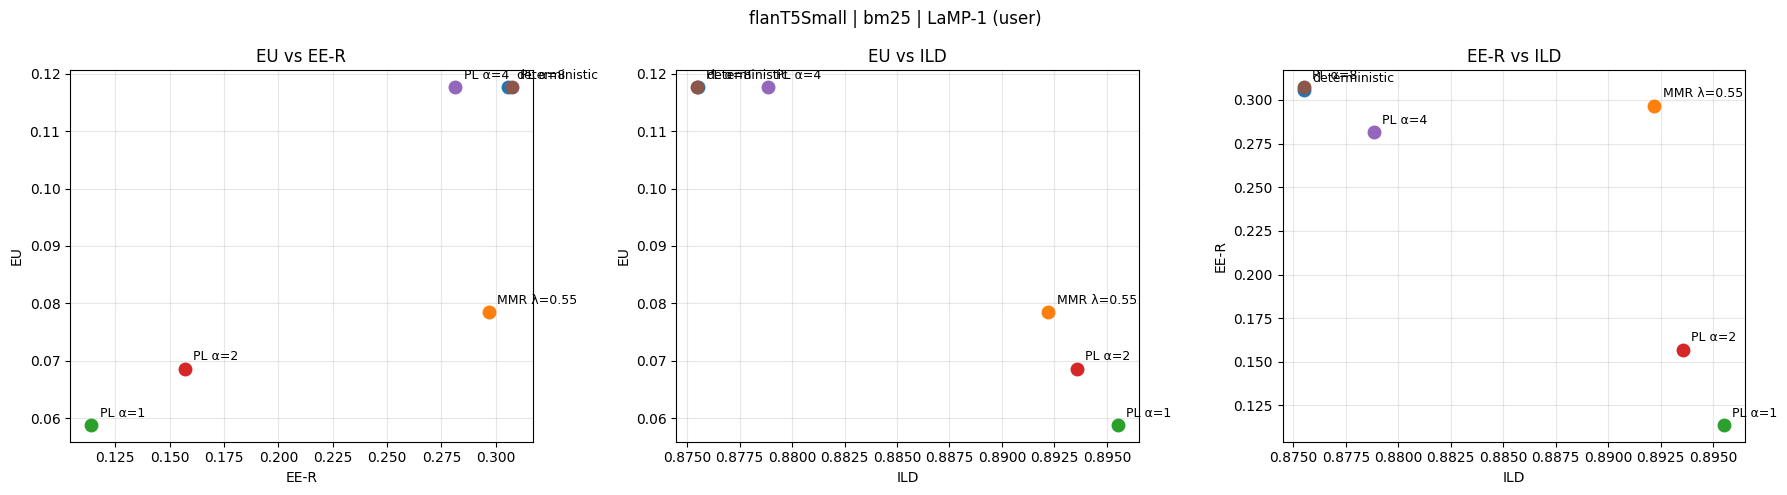

Macro comparison rows:


,dataset,ranking model,LLM model,re-ranking method,EU,ILD,Jaccard,EE-D,EE-R
0,lamp:1:user,bm25,flanT5Small,deterministic,0.117647,0.875496,0.124504,1.000000,0.305603
1,lamp:1:user,bm25,flanT5Small,mmr(λ=0.55),0.078431,0.892207,0.107793,1.000000,0.296762
2,lamp:1:user,bm25,flanT5Small,"pl(a=1, s=10)",0.058824,0.895525,0.104475,0.150275,0.113871
3,lamp:1:user,bm25,flanT5Small,"pl(a=2, s=10)",0.068627,0.893574,0.106426,0.178039,0.156987
4,lamp:1:user,bm25,flanT5Small,"pl(a=4, s=10)",0.117647,0.878841,0.121159,0.697882,0.281387
5,lamp:1:user,bm25,flanT5Small,"pl(a=8, s=10)",0.117647,0.875487,0.124513,0.964235,0.307319



Loaded rows:
  Run-level rows  : 6
  Query-level rows: (hidden)


In [18]:
import pandas as pd
from analysis import plot_metric_scatter_panels, format_macro_table_for_display

macro_rows = build_macro_comparison_rows(run_dirs)
macro_table = maybe_to_dataframe(macro_rows)

if isinstance(macro_table, pd.DataFrame) and not macro_table.empty:
    plot_metric_scatter_panels(
        macro_table,
        panels=[
            ("ee_relevance", "expected_utility", "EE-R", "EU"),
            ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
            ("avg_ild_jaccard", "ee_relevance", "ILD", "EE-R"),
        ],
        label_col="rerank_method",
        title=f"Results — LaMP-{base_cfg.dataset.lamp_num}, {base_cfg.retrieval.ranker}, {base_cfg.generation.generator_name}",
    )
    print("Macro rows:")
    display(format_macro_table_for_display(macro_table))
else:
    print("No completed runs to plot yet.")


## BM25 Reranking Sweep — LaMP 1-7 (deterministic, MMR λ=0.55, PL α∈{1,2,4,8})

Runs the same reranking comparison across all seven LaMP tasks in one loop (BM25, flanT5Small, all queries). Uses `BatchExperimentRunner`'s `reuse_policy="smart"`, so re-running this cell safely skips completed settings and resumes interrupted ones — no manual per-run resume cells needed.

In [ ]:
BM25_SWEEP_OVERRIDES = [
    {"ranker": "bm25", "rerank_method": "deterministic"},
    {"ranker": "bm25", "rerank_method": "mmr", "mmr_lambda": 0.55},
    {"ranker": "bm25", "rerank_method": "pl", "pl_alpha": 1, "pl_samples": 10},
    {"ranker": "bm25", "rerank_method": "pl", "pl_alpha": 2, "pl_samples": 10},
    {"ranker": "bm25", "rerank_method": "pl", "pl_alpha": 4, "pl_samples": 10},
    {"ranker": "bm25", "rerank_method": "pl", "pl_alpha": 8, "pl_samples": 10},
]

def _base_cfg_for_bm25_sweep(lamp_num):
    return RunConfig(
        dataset=DatasetConfig(dataset_type="lamp", lamp_num=lamp_num, lamp_split_type="user", num_queries=None),
        retrieval=RetrievalConfig(ranker="bm25", top_k=5),
        rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=42),
        generation=GenerationConfig(generator_name="flanT5Small", multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
        resume=False, run_id=None,
    )

bm25_sweep_run_dirs = {}
for lamp_num in range(1, 8):
    base = _base_cfg_for_bm25_sweep(lamp_num)
    cfgs = [build_cfg_from_override(base, o) for o in BM25_SWEEP_OVERRIDES]
    print(f"LaMP-{lamp_num} settings:")
    for c in cfgs:
        print("  -", setting_id(c))
    batch = BatchExperimentRunner(cfgs, batch_id=f"lamp{lamp_num}_bm25_mmr_pl", reuse_policy="smart")
    out = batch.run_all()
    bm25_sweep_run_dirs[lamp_num] = out["run_dirs"]
    print(f"LaMP-{lamp_num} batch complete. Dirs:")
    for d in out["run_dirs"]:
        print("  -", d)


In [ ]:
from analysis import plot_metric_scatter_panels, format_macro_table_for_display, format_rerank_label

_bm25_panels = [
    ("ee_relevance", "expected_utility", "EE-R", "EU"),
    ("avg_ild_jaccard", "expected_utility", "ILD", "EU"),
    ("avg_ild_jaccard", "ee_relevance", "ILD", "EE-R"),
]

for lamp_num, run_dirs_for_lamp in bm25_sweep_run_dirs.items():
    macro_rows = build_macro_comparison_rows(run_dirs_for_lamp)
    macro_table = maybe_to_dataframe(macro_rows)
    plot_metric_scatter_panels(
        macro_table,
        panels=_bm25_panels,
        label_fn=lambda row: format_rerank_label(row, ranker_prefix=True),
        title=f"BM25 reranking comparison — flanT5Small, LaMP-{lamp_num}, all queries",
    )
    print(f"LaMP-{lamp_num} macro rows:")
    display(format_macro_table_for_display(macro_table))


## Additional Runs: MMR Sweep + Missing Gold-Det

This cell runs only missing settings for each LaMP task:
- BM25 + MMR with λ in {0.25, 0.45, 0.65, 0.85}
- Gold + deterministic (only if not already present)

Existing runs are detected by `setting_id` and skipped.

In [10]:
import copy
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

MMR_LAMBDAS_EXTRA = [0.25, 0.45, 0.65, 0.85]
GEN = "flanT5Small"
SPLIT = "user"
TOP_K = 5
SEED = 42

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(f"Existing run dirs scanned: {len(all_run_dirs)}")
print(f"Existing setting IDs found: {len(existing_sids)}")


def _base_cfg_for_lamp(lamp_num):
    return RunConfig(
        dataset=DatasetConfig(dataset_type="lamp", lamp_num=lamp_num, lamp_split_type=SPLIT, num_queries=None),
        retrieval=RetrievalConfig(ranker="bm25", top_k=TOP_K),
        rerank=RerankConfig(method="mmr", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=SEED),
        generation=GenerationConfig(generator_name=GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
        resume=False,
        run_id=None,
    )


missing_total = 0
for lamp_num in range(1, 8):
    base = _base_cfg_for_lamp(lamp_num)
    missing_cfgs = []

    # Extra MMR lambdas
    for lam in MMR_LAMBDAS_EXTRA:
        cfg = copy.deepcopy(base)
        cfg.retrieval.ranker = "bm25"
        cfg.rerank.method = "mmr"
        cfg.rerank.mmr_lambda = lam
        cfg.rerank.seed = SEED
        cfg.resume = False
        cfg.run_id = None

        sid = setting_id(cfg)
        if sid not in existing_sids:
            missing_cfgs.append(cfg)

    # Gold deterministic only if missing
    gold_cfg = copy.deepcopy(base)
    gold_cfg.retrieval.ranker = "gold"
    gold_cfg.rerank.method = "deterministic"
    gold_cfg.rerank.seed = SEED
    gold_cfg.resume = False
    gold_cfg.run_id = None

    gold_sid = setting_id(gold_cfg)
    if gold_sid not in existing_sids:
        missing_cfgs.append(gold_cfg)

    if not missing_cfgs:
        print(f"LaMP-{lamp_num}: nothing missing (skipped)")
        continue

    print(f"LaMP-{lamp_num}: running {len(missing_cfgs)} missing setting(s)")
    for cfg in missing_cfgs:
        print(f"  - {setting_id(cfg)}")

    batch = BatchExperimentRunner(
        missing_cfgs,
        batch_id=f"lamp{lamp_num}_mmr_sweep_plus_gold_det",
        reuse_policy="smart",
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])
    print(f"LaMP-{lamp_num}: complete, produced/confirmed {len(run_dirs)} run dir(s)")

    for cfg in missing_cfgs:
        existing_sids.add(setting_id(cfg))
    missing_total += len(missing_cfgs)

print(f"Done. Total missing settings executed: {missing_total}")

Existing run dirs scanned: 63
Existing setting IDs found: 56
LaMP-1: running 1 missing setting(s)
  - lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
[Batch] Starting run 1/1: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
Setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.9864, ILD=0.8867, EU=0.3000
Setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42 | Average after 51 queries: EE-D=1.0000, EE-R=0.9856, ILD=0.8865, EU=0.2941
Completed setting: lamp1_user__flanT5Small__gold__det__k5__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260419_113735_lamp1_user__flanT5Small__gold__det__k5__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260419_113735_lamp1_user__flanT5Small__gold__det__k5__nqall__seed42/macro_summary.json
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_run

In [9]:
import os
import json
import pandas as pd

for lamp_num in range(1, 8):
    gold_fp = os.path.join(
        REPO_ROOT,
        "retrieval",
        "retrieval_results",
        "flanT5Small",
        "gold",
        f"{lamp_num}.json",
    )
    if os.path.exists(gold_fp):
        print(f"Gold retrieval exists for LaMP-{lamp_num}: {gold_fp}")
        continue

    rel_fp = os.path.join(
        REPO_ROOT,
        "data",
        "lamp_utility_labels_flanT5Small",
        f"{lamp_num}_relevance_mapping.tsv",
    )
    out_fp = os.path.join(
        REPO_ROOT,
        "data",
        "lamp_utility_labels_flanT5Small",
        f"{lamp_num}_user_dev_outputs.json",
    )

    if not os.path.exists(rel_fp):
        raise FileNotFoundError(f"Missing relevance mapping: {rel_fp}")
    if not os.path.exists(out_fp):
        raise FileNotFoundError(f"Missing utility-label outputs: {out_fp}")

    with open(out_fp, "r", encoding="utf-8") as f:
        out_json = json.load(f)
    final_qids = [entry["id"] for entry in out_json.get("golds", [])]

    rel_df = pd.read_csv(rel_fp, sep="\t", dtype={"qid": str, "pid": str})
    rel_df = rel_df[rel_df["qid"].isin(final_qids)][["qid", "pid", "relevance_label"]]

    rank_dict = {}
    for qid in final_qids:
        qdf = rel_df[rel_df["qid"] == qid].copy()
        qdf = qdf.sort_values(by=["relevance_label", "pid"], ascending=[False, False])
        rank_dict[qid] = [(pid, int(lbl)) for pid, lbl in zip(qdf["pid"].tolist(), qdf["relevance_label"].tolist())]

    os.makedirs(os.path.dirname(gold_fp), exist_ok=True)
    with open(gold_fp, "w", encoding="utf-8") as f:
        json.dump(rank_dict, f)

    print(f"Generated gold retrieval for LaMP-{lamp_num}: {gold_fp}")

print("Gold retrieval precompute check complete.")

Generated gold retrieval for LaMP-1: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/1.json
Gold retrieval exists for LaMP-2: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/2.json
Generated gold retrieval for LaMP-3: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/3.json
Gold retrieval exists for LaMP-4: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/4.json
Generated gold retrieval for LaMP-5: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/5.json
Generated gold retrieval for LaMP-6: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/6.json
Generated gold retrieval for LaMP-7: /Users/asimk/Code/Fair-RAG/retrieval/retrieval_results/flanT5Small/gold/7.json
Gold retrieval precompute check complete.


## SPLADE + Contriever Full Sweep (LaMP 1-7)

Runs the missing deterministic / MMR (λ∈{0.25,0.45,0.55,0.65,0.85}) / PL (α∈{1,2,4,8}) settings for both SPLADE and Contriever across LaMP tasks (SPLADE skips LaMP-1 — no retrieval data for it; Contriever covers all 7). Uses `reuse_policy="smart"` so already-completed settings are skipped automatically; precomputes retrieval on demand via `retrieval/rank_profiles.py` if missing.

In [ ]:
import copy
import os
import subprocess
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

RANKER_SWEEP_LAMPS = {
    "splade": [2, 3, 4, 5, 6, 7],
    "contriever": [1, 2, 3, 4, 5, 6, 7],
}
SWEEP_GEN = "flanT5Small"
SWEEP_SPLIT = "user"
SWEEP_TOP_K = 5
SWEEP_SEED = 42
SWEEP_REUSE_POLICY = "smart"
SWEEP_NUM_QUERIES = None
SWEEP_MMR_LAMBDAS = [0.25, 0.45, 0.55, 0.65, 0.85]

SWEEP_OVERRIDES = [{"rerank_method": "deterministic"}]
for lam in SWEEP_MMR_LAMBDAS:
    SWEEP_OVERRIDES.append({"rerank_method": "mmr", "mmr_lambda": lam})
SWEEP_OVERRIDES.extend(
    [
        {"rerank_method": "pl", "pl_alpha": 1, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 2, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 4, "pl_samples": 10},
        {"rerank_method": "pl", "pl_alpha": 8, "pl_samples": 10},
    ]
)


def _ensure_retrieval(ranker, generator_name, lamp_num):
    fp = os.path.join(
        REPO_ROOT,
        "retrieval",
        "retrieval_results",
        generator_name,
        ranker,
        f"{lamp_num}.json",
    )
    if os.path.exists(fp):
        return fp, "exists"

    cmd = [
        "python",
        "retrieval/rank_profiles.py",
        "--ranker",
        ranker,
        "--generator_name",
        generator_name,
        "--lamp_num",
        str(lamp_num),
    ]

    try:
        subprocess.run(cmd, cwd=REPO_ROOT, check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            f"{ranker} retrieval generation failed for LaMP-{lamp_num}."
        ) from exc

    return fp, "generated"


all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

for ranker, lamps in RANKER_SWEEP_LAMPS.items():
    print(
        f"{ranker} run stage: lamps={lamps}, num_queries={SWEEP_NUM_QUERIES}, "
        f"reuse_policy={SWEEP_REUSE_POLICY}, verbose=True (progress every 40 queries)"
    )
    print(f"MMR lambdas: {SWEEP_MMR_LAMBDAS}")
    print(f"Existing setting IDs loaded: {len(existing_sids)}")
    print()

    for lamp_num in lamps:
        fp, retrieval_status = _ensure_retrieval(ranker, SWEEP_GEN, lamp_num)

        base = RunConfig(
            dataset=DatasetConfig(
                dataset_type="lamp",
                lamp_num=lamp_num,
                lamp_split_type=SWEEP_SPLIT,
                num_queries=SWEEP_NUM_QUERIES,
            ),
            retrieval=RetrievalConfig(ranker=ranker, top_k=SWEEP_TOP_K),
            rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.65, seed=SWEEP_SEED),
            generation=GenerationConfig(generator_name=SWEEP_GEN, multi_gpu=False),
            metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
            checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
            resume=False,
            run_id=None,
        )

        cfgs = []
        for ov in SWEEP_OVERRIDES:
            cfg = copy.deepcopy(base)
            cfg.rerank.method = ov["rerank_method"]
            if "mmr_lambda" in ov:
                cfg.rerank.mmr_lambda = ov["mmr_lambda"]
            if "pl_alpha" in ov:
                cfg.rerank.pl_alpha = ov["pl_alpha"]
            if "pl_samples" in ov:
                cfg.rerank.pl_samples = ov["pl_samples"]
            sid = setting_id(cfg)
            if sid not in existing_sids:
                cfgs.append(cfg)

        if not cfgs:
            print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, settings=0 (all already present)")
            continue

        print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, running {len(cfgs)} missing setting(s)")
        for cfg in cfgs:
            print(f"  - {setting_id(cfg)}")
        print()

        batch = BatchExperimentRunner(
            cfgs,
            batch_id=f"lamp{lamp_num}_{ranker}_allq_mmr_sweep_pl",
            reuse_policy=SWEEP_REUSE_POLICY,
        )
        out = batch.run_all()
        run_dirs = out.get("run_dirs", [])

        for cfg in cfgs:
            existing_sids.add(setting_id(cfg))

        print(f"LaMP-{lamp_num}: complete, produced {len(run_dirs)} run dir(s)")
        print("-" * 80)
        print()

    print("=" * 80)
    print(f"{ranker} run stage complete.")
    print("=" * 80)


## Gold Retrieval k=3 Sweep (LaMP 1-7)

Runs missing gold+deterministic settings with top_k=3 across datasets, using smart reuse so existing runs are skipped.

In [3]:
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

GOLD_K3_LAMPS = [1, 2, 3, 4, 5, 6, 7]
GOLD_K3_GEN = "flanT5Small"
GOLD_K3_SPLIT = "user"
GOLD_K3_TOP_K = 3
GOLD_K3_SEED = 42
GOLD_K3_REUSE_POLICY = "smart"
GOLD_K3_NUM_QUERIES = None

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(
    f"Gold k=3 stage: lamps={GOLD_K3_LAMPS}, generator={GOLD_K3_GEN}, split={GOLD_K3_SPLIT}, "
    f"top_k={GOLD_K3_TOP_K}, reuse_policy={GOLD_K3_REUSE_POLICY}"
)
print(f"Existing setting IDs loaded: {len(existing_sids)}")
print()

executed_cfgs = 0
executed_run_dirs = []

for lamp_num in GOLD_K3_LAMPS:
    cfg = RunConfig(
        dataset=DatasetConfig(
            dataset_type="lamp",
            lamp_num=lamp_num,
            lamp_split_type=GOLD_K3_SPLIT,
            num_queries=GOLD_K3_NUM_QUERIES,
        ),
        retrieval=RetrievalConfig(ranker="gold", top_k=GOLD_K3_TOP_K),
        rerank=RerankConfig(method="deterministic", pl_alpha=4, pl_samples=10, mmr_lambda=0.55, seed=GOLD_K3_SEED),
        generation=GenerationConfig(generator_name=GOLD_K3_GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=50),
        resume=False,
        run_id=None,
    )

    sid = setting_id(cfg)
    if sid in existing_sids:
        print(f"LaMP-{lamp_num}: already present, skipped")
        continue

    print(f"LaMP-{lamp_num}: running {sid}")
    batch = BatchExperimentRunner(
        [cfg],
        batch_id=f"lamp{lamp_num}_gold_det_k3",
        reuse_policy=GOLD_K3_REUSE_POLICY,
    )
    out = batch.run_all()
    produced = out.get("run_dirs", [])
    executed_run_dirs.extend(produced)
    existing_sids.add(sid)
    executed_cfgs += 1
    print(f"LaMP-{lamp_num}: complete, produced/confirmed {len(produced)} run dir(s)")
    print()

print("=" * 80)
print(f"Gold k=3 stage complete. New settings executed: {executed_cfgs}")
if executed_run_dirs:
    print("Run directories:")
    for path in executed_run_dirs:
        print(f"  - {path}")
print("=" * 80)

Gold k=3 stage: lamps=[1, 2, 3, 4, 5, 6, 7], generator=flanT5Small, split=user, top_k=3, reuse_policy=smart
Existing setting IDs loaded: 226

LaMP-1: running lamp1_user__flanT5Small__gold__det__k3__nqall__seed42
[Batch] Starting run 1/1: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42
Setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42


Loading weights: 100%|██████████| 190/190 [00:00<00:00, 24007.89it/s]


Setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42 | Average after 50 queries: EE-D=1.0000, EE-R=0.9986, ILD=0.8787, EU=0.4800
Setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42 | Average after 51 queries: EE-D=1.0000, EE-R=0.9985, ILD=0.8773, EU=0.4706
Completed setting: lamp1_user__flanT5Small__gold__det__k3__nqall__seed42
Summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260504_104957_lamp1_user__flanT5Small__gold__det__k3__nqall__seed42/summary.json
Macro summary: /Users/asimk/Code/Fair-RAG/experiment_runs/20260504_104957_lamp1_user__flanT5Small__gold__det__k3__nqall__seed42/macro_summary.json
[Batch] Summary written to /Users/asimk/Code/Fair-RAG/experiment_runs/batches/lamp1_gold_det_k3/batch_summary.json
LaMP-1: complete, produced/confirmed 1 run dir(s)

LaMP-2: running lamp2_user__flanT5Small__gold__det__k3__nqall__seed42
[Batch] Starting run 1/1: lamp2_user__flanT5Small__gold__det__k3__nqall__seed42
Setting: lamp2_user__flanT5Small__gold__det__k3__nq

## SPLADE k=3 Sweep + EE-D/EU Tables

Runs missing SPLADE settings at k=3 (deterministic, MMR sweep, PL sweep) and then builds EE-D vs EU summary tables from completed runs.

In [7]:
import copy
import os
import subprocess
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

SPLADE_K3_LAMPS = [1, 2, 3, 4, 5, 6, 7]
SPLADE_K3_GEN = "flanT5Small"
SPLADE_K3_SPLIT = "user"
SPLADE_K3_TOP_K = 3
SPLADE_K3_SEED = 42
SPLADE_K3_REUSE_POLICY = "smart"
SPLADE_K3_NUM_QUERIES = None
SPLADE_K3_MMR_LAMBDAS = [0.25, 0.45, 0.55, 0.65, 0.85]
SPLADE_K3_PL_ALPHAS = [1, 2, 4, 8]
SPLADE_K3_PL_SAMPLES = 10

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

print(
    f"SPLADE k=3 stage: lamps={SPLADE_K3_LAMPS}, top_k={SPLADE_K3_TOP_K}, "
    f"num_queries={SPLADE_K3_NUM_QUERIES}, reuse_policy={SPLADE_K3_REUSE_POLICY}"
)
print(f"Existing setting IDs loaded: {len(existing_sids)}")
print()

splade_k3_new_run_dirs = []
splade_k3_executed_cfgs = 0

for lamp_num in SPLADE_K3_LAMPS:
    _, retrieval_status = _ensure_retrieval("splade", SPLADE_K3_GEN, lamp_num)

    base = RunConfig(
        dataset=DatasetConfig(
            dataset_type="lamp",
            lamp_num=lamp_num,
            lamp_split_type=SPLADE_K3_SPLIT,
            num_queries=SPLADE_K3_NUM_QUERIES,
        ),
        retrieval=RetrievalConfig(ranker="splade", top_k=SPLADE_K3_TOP_K),
        rerank=RerankConfig(
            method="deterministic",
            pl_alpha=4,
            pl_samples=SPLADE_K3_PL_SAMPLES,
            mmr_lambda=0.55,
            seed=SPLADE_K3_SEED,
        ),
        generation=GenerationConfig(generator_name=SPLADE_K3_GEN, multi_gpu=False),
        metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
        checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
        resume=False,
        run_id=None,
    )

    overrides = [{"rerank_method": "deterministic"}]
    overrides.extend({"rerank_method": "mmr", "mmr_lambda": lam} for lam in SPLADE_K3_MMR_LAMBDAS)
    overrides.extend(
        {"rerank_method": "pl", "pl_alpha": a, "pl_samples": SPLADE_K3_PL_SAMPLES}
        for a in SPLADE_K3_PL_ALPHAS
    )

    cfgs = []
    for ov in overrides:
        cfg = copy.deepcopy(base)
        cfg.rerank.method = ov["rerank_method"]
        if "mmr_lambda" in ov:
            cfg.rerank.mmr_lambda = ov["mmr_lambda"]
        if "pl_alpha" in ov:
            cfg.rerank.pl_alpha = ov["pl_alpha"]
        if "pl_samples" in ov:
            cfg.rerank.pl_samples = ov["pl_samples"]

        sid = setting_id(cfg)
        if sid not in existing_sids:
            cfgs.append(cfg)

    if not cfgs:
        print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, settings=0 (all already present)")
        continue

    print(f"LaMP-{lamp_num}: retrieval={retrieval_status}, running {len(cfgs)} missing setting(s)")
    for cfg in cfgs:
        print(f"  - {setting_id(cfg)}")
    print()

    batch = BatchExperimentRunner(
        cfgs,
        batch_id=f"lamp{lamp_num}_splade_k3_mmr_sweep_pl",
        reuse_policy=SPLADE_K3_REUSE_POLICY,
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])
    splade_k3_new_run_dirs.extend(run_dirs)

    for cfg in cfgs:
        existing_sids.add(setting_id(cfg))
    splade_k3_executed_cfgs += len(cfgs)

    print(f"LaMP-{lamp_num}: complete, produced/confirmed {len(run_dirs)} run dir(s)")
    print("-" * 80)
    print()

print("=" * 80)
print(f"SPLADE k=3 stage complete. New settings executed: {splade_k3_executed_cfgs}")
if splade_k3_new_run_dirs:
    print("Run directories:")
    for d in splade_k3_new_run_dirs:
        print(f"  - {d}")
print("=" * 80)

SPLADE k=3 stage: lamps=[1, 2, 3, 4, 5, 6, 7], top_k=3, num_queries=None, reuse_policy=smart
Existing setting IDs loaded: 303

LaMP-1: retrieval=exists, settings=0 (all already present)
LaMP-2: retrieval=exists, settings=0 (all already present)
LaMP-3: retrieval=exists, settings=0 (all already present)
LaMP-4: retrieval=exists, settings=0 (all already present)
LaMP-5: retrieval=exists, settings=0 (all already present)
LaMP-6: retrieval=exists, settings=0 (all already present)
LaMP-7: retrieval=exists, settings=0 (all already present)
SPLADE k=3 stage complete. New settings executed: 0


## PL-MMR Hybrid: SPLADE k=5, LaMP 4

In [4]:
# Run additional PL-MMR configurations (alpha=1,2)
import copy
import os
from framework import (
    BatchExperimentRunner,
    CheckpointConfig,
    DatasetConfig,
    GenerationConfig,
    MetricsConfig,
    RetrievalConfig,
    RerankConfig,
    RunConfig,
    build_macro_comparison_rows,
    list_run_dirs,
    setting_id,
)

# Be robust to kernel restarts.
REPO_ROOT = globals().get("REPO_ROOT", os.path.abspath(os.getcwd()))
PLMMR_LAMP = globals().get("PLMMR_LAMP", 4)
PLMMR_GEN = globals().get("PLMMR_GEN", "flanT5Small")
PLMMR_SPLIT = globals().get("PLMMR_SPLIT", "user")
PLMMR_TOP_K = globals().get("PLMMR_TOP_K", 5)
PLMMR_SEED = globals().get("PLMMR_SEED", 42)
PLMMR_REUSE_POLICY = globals().get("PLMMR_REUSE_POLICY", "smart")
PLMMR_NUM_QUERIES = globals().get("PLMMR_NUM_QUERIES", None)
PLMMR_LAMBDA = globals().get("PLMMR_LAMBDA", 0.55)
PLMMR_SAMPLES = globals().get("PLMMR_SAMPLES", 10)

additional_alphas = [1, 2]

all_run_dirs = list_run_dirs(os.path.join(REPO_ROOT, "experiment_runs"))
all_rows = build_macro_comparison_rows(all_run_dirs)
existing_sids = {r.get("setting_id") for r in all_rows if r.get("setting_id")}

base = RunConfig(
    dataset=DatasetConfig(
        dataset_type="lamp",
        lamp_num=PLMMR_LAMP,
        lamp_split_type=PLMMR_SPLIT,
        num_queries=PLMMR_NUM_QUERIES,
    ),
    retrieval=RetrievalConfig(ranker="splade", top_k=PLMMR_TOP_K),
    rerank=RerankConfig(
        method="pl_mmr",
        pl_alpha=1,
        pl_samples=PLMMR_SAMPLES,
        mmr_lambda=PLMMR_LAMBDA,
        seed=PLMMR_SEED,
    ),
    generation=GenerationConfig(generator_name=PLMMR_GEN, multi_gpu=False),
    metrics=MetricsConfig(compute_ee=True, compute_eu=True, compute_diversity=True),
    checkpoint=CheckpointConfig(flush_every=1, report_every_queries=40),
    resume=False,
    run_id=None,
)

cfgs = []
for alpha in additional_alphas:
    cfg = copy.deepcopy(base)
    cfg.rerank.pl_alpha = alpha
    sid = setting_id(cfg)
    if sid not in existing_sids:
        cfgs.append(cfg)
    else:
        print(f"alpha={alpha}: already present ({sid}), skipping")

if not cfgs:
    print("No missing alpha settings among [1, 2].")
else:
    print(f"Running {len(cfgs)} missing PL-MMR setting(s) for LaMP-{PLMMR_LAMP}:")
    for cfg in cfgs:
        print(f"  - {setting_id(cfg)}")
    print()

    batch = BatchExperimentRunner(
        cfgs,
        batch_id=f"lamp{PLMMR_LAMP}_splade_k{PLMMR_TOP_K}_pl_mmr_a1_a2",
        reuse_policy=PLMMR_REUSE_POLICY,
    )
    out = batch.run_all()
    run_dirs = out.get("run_dirs", [])

    print("\nAlpha=1/2 stage complete. Run dir(s):")
    for d in run_dirs:
        print(f"  - {d}")


Running 2 missing PL-MMR setting(s) for LaMP-4:
  - lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42
  - lamp4_user__flanT5Small__splade__pl_mmr_a2_l055_s10__k5__nqall__seed42

[Batch] Starting run 1/2: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 40 queries: EE-D=0.1483, EE-R=0.1945, ILD=0.9486, EU=0.0285
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 80 queries: EE-D=0.1664, EE-R=0.2690, ILD=0.9411, EU=0.0336
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 120 queries: EE-D=0.2155, EE-R=0.3281, ILD=0.9367, EU=0.0404
Setting: lamp4_user__flanT5Small__splade__pl_mmr_a1_l055_s10__k5__nqall__seed42 | Average after 160 queries: EE-D=0.1896, EE-R=0.3085, ILD=0.9388, EU=0.040